# Seleção do modelo — experimentos, hipóteses e ajuste com Optuna

**Moeda adotada:** dólar americano (USD), por premissa do projeto baseada no contexto de Seattle. Não houve conversão cambial nem alteração dos valores. A fonte não confirmou explicitamente a moeda. Preços e erros monetários estão em USD; percentuais, R² e contribuições SHAP em log mantêm suas próprias escalas.

## Objetivo
Comparar quatro algoritmos nas mesmas janelas temporais do notebook 04, investigar o benefício das variáveis candidatas e congelar uma configuração para a avaliação final do notebook 06.

**Sequência:** comparação inicial com 18 entradas físicas → grupos de variáveis nos dois melhores candidatos → preço original versus logaritmo na combinação escolhida → Optuna limitado → escolha documentada. O teste final e os exemplos futuros não participam desses experimentos.

**Critério principal:** MAE médio das três janelas, sempre na escala original de preço. Entre combinações com erro até 1% acima do menor MAE observado, preferimos menos colunas; depois, menor MAE. Essa margem operacional foi definida antes da execução para evitar maior dependência de dados por um ganho muito pequeno; não é um teste de significância estatística.

**Recursos:** no máximo duas threads numéricas, experimentos sequenciais, árvores com tamanho limitado e Optuna com até oito tentativas ou 90 segundos. Há um orçamento orientativo de cinco minutos de ajuste e previsão, sem contar pausas de leitura; um ajuste já iniciado pode terminar após o limite. O tempo é verificado entre etapas, não é uma interrupção rígida de processos.

**Limitações:** a EDA considerou o histórico completo e estas janelas serão reutilizadas para várias escolhas. Por isso, o melhor resultado de validação pode ser otimista e exige a avaliação final separada. Datas e definições dos indicadores demográficos permanecem pendentes: seu uso aqui é experimental, não certificação de disponibilidade em produção.

**Execução:** use o Python da `.venv` e execute em ordem. Os resultados sobrescrevem os relatórios desta etapa; os arquivos de split e os dados não são modificados. Nenhum modelo é ajustado no teste.

In [1]:
# Limita o paralelismo e prepara o ambiente de experimentação.
import os
for nome_limite in ["OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "NUMEXPR_NUM_THREADS"]:
    os.environ[nome_limite] = "2"

from pathlib import Path
from time import perf_counter
import gc
import hashlib
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import psutil
import sklearn
import optuna
import xgboost
import lightgbm
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from IPython.display import display as exibir
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from threadpoolctl import threadpool_limits

PASTA_PROJETO = Path.cwd()
if not (PASTA_PROJETO / "data" / "processed").is_dir():
    PASTA_PROJETO = PASTA_PROJETO.parent
PASTA_DADOS = PASTA_PROJETO / "data" / "processed"
PASTA_RESULTADOS = PASTA_PROJETO / "reports" / "metrics"
PASTA_GRAFICOS = PASTA_PROJETO / "reports" / "figures"
PASTA_ARTEFATOS = PASTA_PROJETO / "artifacts"
for pasta in [PASTA_RESULTADOS, PASTA_GRAFICOS, PASTA_ARTEFATOS]:
    pasta.mkdir(parents=True, exist_ok=True)

SEMENTE = 42
LIMITE_THREADS = 2
MAX_TENTATIVAS = 8
TEMPO_OPTUNA_SEGUNDOS = 90
TEMPO_EXPERIMENTOS_SEGUNDOS = 300
MARGEM_SIMPLICIDADE = 0.01
MIN_RAM_LIVRE_GIB = 1.0
optuna.logging.set_verbosity(optuna.logging.WARNING)

exibir(pd.DataFrame({
    "recurso": ["RAM disponível (GiB)", "Threads", "Experimentos simultâneos",
                "Tentativas máximas Optuna", "Tempo máximo da busca (s)"],
    "valor": [round(psutil.virtual_memory().available / 2**30, 2), LIMITE_THREADS, 1,
              MAX_TENTATIVAS, TEMPO_OPTUNA_SEGUNDOS],
}))

c:\Users\Pichau\Desktop\Desafio Técnico GenAI\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,recurso,valor
0,RAM disponível (GiB),6.28
1,Threads,2.00
2,Experimentos simultâneos,1.00
3,Tentativas máximas Optuna,8.00
4,Tempo máximo da busca (s),90.00


**O que o resultado mostra**

A configuração limita paralelismo e tamanho da busca. A RAM disponível é medida no momento da execução e pode variar com outros programas.

**Por que fizemos esta análise e o que decidimos**

Não vamos treinar todas as combinações de colunas em todos os algoritmos. A exploração será gradual e reutilizará resultados idênticos na mesma execução. Antes de cada ajuste, verificamos se há pelo menos 1 GiB livre; essa checagem não equivale a um limite rígido de memória.

O limite global de 300 segundos contabiliza os ajustes e as previsões, sem contar pausas de leitura entre células. A verificação ocorre antes de iniciar o próximo ajuste; um ajuste em andamento pode ultrapassar o limite. Ridge usa matriz esparsa; os modelos de árvores usam matriz densa, pequena para este conjunto de dados.

## 1. Reutilizando as mesmas vendas de treino e validação

A comparação só é coerente se os candidatos forem avaliados nas mesmas vendas. Conferimos os hashes registrados no notebook 04 e reconstruímos os índices a partir dos manifestos, sem gerar novo split.

In [2]:
# Confere fontes e reconstrução das três janelas, sem acessar preços do teste para métricas.
protocolo_baseline = json.loads((PASTA_RESULTADOS / "baseline_protocolo.json").read_text(encoding="utf-8"))
contrato = json.loads((PASTA_DADOS / "contrato_features.json").read_text(encoding="utf-8"))
for nome_arquivo, hash_esperado in protocolo_baseline["source_sha256"].items():
    if hashlib.sha256((PASTA_DADOS / nome_arquivo).read_bytes()).hexdigest() != hash_esperado:
        raise ValueError(f"Arquivo ou versão incompatível: {nome_arquivo}")

todas_variaveis = pd.read_csv(PASTA_DADOS / "features_historico.csv", dtype={"zipcode": "string"})
identificacao = pd.read_csv(PASTA_DADOS / "identificacao_alvo_historico.csv", dtype={"id": "string"})
manifesto_split = pd.read_csv(PASTA_DADOS / "split_manifest.csv", dtype={"id": "string"})
manifesto_cv = pd.read_csv(PASTA_DADOS / "cv_manifest.csv")
if todas_variaveis.columns.tolist() != contrato['colunas_saida_ordenadas']:
    raise ValueError('Entradas ou partições incompatíveis com o protocolo. Confira a condição indicada.')
if identificacao['linha_origem'].tolist() != list(range(len(todas_variaveis))):
    raise ValueError('Entradas ou partições incompatíveis com o protocolo. Confira a condição indicada.')
if manifesto_split['source_row'].tolist() != identificacao['linha_origem'].tolist():
    raise ValueError('Entradas ou partições incompatíveis com o protocolo. Confira a condição indicada.')
if not (manifesto_split["id"].equals(identificacao["id"])):
    raise ValueError('Entradas ou partições incompatíveis com o protocolo. Confira a condição indicada.')
if not (pd.to_datetime(manifesto_split["date"]).equals(pd.to_datetime(identificacao["date"], format="%Y%m%dT%H%M%S"))):
    raise ValueError('Entradas ou partições incompatíveis com o protocolo. Confira a condição indicada.')
if manifesto_split['partition'].value_counts().to_dict() != protocolo_baseline['split_counts']:
    raise ValueError('Entradas ou partições incompatíveis com o protocolo. Confira a condição indicada.')
if set(manifesto_cv['fold']) != {1, 2, 3}:
    raise ValueError('Entradas ou partições incompatíveis com o protocolo. Confira a condição indicada.')
if set(manifesto_cv['role']) != {'train', 'validation', 'excluded_overlap'}:
    raise ValueError('Entradas ou partições incompatíveis com o protocolo. Confira a condição indicada.')
if manifesto_cv.duplicated(['fold', 'source_row']).any():
    raise ValueError('Entradas ou partições incompatíveis com o protocolo. Confira a condição indicada.')

linhas_permitidas = manifesto_split.loc[manifesto_split["partition"].eq("train_validation"), "source_row"]
linhas_teste = set(manifesto_split.loc[manifesto_split["partition"].eq("test"), "source_row"])
ids_teste = set(manifesto_split.loc[manifesto_split["partition"].eq("test"), "id"])
if not (set(manifesto_cv["source_row"]) <= set(linhas_permitidas)):
    raise ValueError('Entradas ou partições incompatíveis com o protocolo. Confira a condição indicada.')
entradas = todas_variaveis.loc[linhas_permitidas].copy()
precos = identificacao.set_index("linha_origem").loc[linhas_permitidas, "price"]
metadados = identificacao.set_index("linha_origem").loc[linhas_permitidas, ["id", "date"]].copy()
metadados["date"] = pd.to_datetime(metadados["date"], format="%Y%m%dT%H%M%S")
del todas_variaveis, identificacao

particoes = []
for janela in sorted(manifesto_cv["fold"].unique()):
    indices_treino = manifesto_cv.loc[manifesto_cv["fold"].eq(janela) & manifesto_cv["role"].eq("train"), "source_row"].to_numpy()
    indices_validacao = manifesto_cv.loc[manifesto_cv["fold"].eq(janela) & manifesto_cv["role"].eq("validation"), "source_row"].to_numpy()
    if not (metadados.loc[indices_treino, "date"].max() < metadados.loc[indices_validacao, "date"].min()):
        raise ValueError('Entradas ou partições incompatíveis com o protocolo. Confira a condição indicada.')
    if set(metadados.loc[indices_treino, 'id']) & set(metadados.loc[indices_validacao, 'id']):
        raise ValueError('Entradas ou partições incompatíveis com o protocolo. Confira a condição indicada.')
    if set(metadados.loc[np.r_[indices_treino, indices_validacao], 'id']) & ids_teste:
        raise ValueError('Entradas ou partições incompatíveis com o protocolo. Confira a condição indicada.')
    particoes.append((indices_treino, indices_validacao))
if manifesto_cv.query("role == 'validation'")['source_row'].duplicated().any():
    raise ValueError('Entradas ou partições incompatíveis com o protocolo. Confira a condição indicada.')
grupos = contrato["grupos_candidatos"]
if grupos['fisicas_originais'] != protocolo_baseline['features']:
    raise ValueError('Entradas ou partições incompatíveis com o protocolo. Confira a condição indicada.')
exibir(pd.DataFrame([
    {"janela": numero, "treino": len(treino), "validacao": len(validacao)}
    for numero, (treino, validacao) in enumerate(particoes, start=1)
]))

,janela,treino,validacao
0,1,11241,2392
1,2,13626,1626
2,3,15235,1917


**O que o resultado mostra**

As janelas têm 11.241/2.392, 13.626/1.626 e 15.235/1.917 registros de treino/validação. Os hashes, datas e IDs são conferidos antes dos experimentos.

**Por que fizemos esta análise e o que decidimos**

Se a fonte ou as partições mudarem, é necessário revisar a comparação. Nenhum ID do teste pode aparecer nas janelas. Os preços usados daqui em diante pertencem apenas ao conjunto de treino e validação; a tabela completa foi descartada da memória após selecionar essa parcela.

## 2. Quatro candidatos e regras de comparação

O alvo é o **preço do imóvel**, um valor numérico contínuo. Por isso, usamos regressão: `Ridge`, `RandomForestRegressor`, `XGBRegressor` e `LGBMRegressor`. As versões `Classifier` seriam usadas para categorias, como “venda de baixo ou alto valor”, que não são nosso objetivo.

**Ridge:** regressão linear com regularização, que limita coeficientes excessivos. É o baseline já validado no notebook 04 e será reaproveitado após conferência das partições e métricas.

**Random Forest:** combina várias árvores treinadas em amostras dos dados.

**XGBoost e LightGBM:** constroem árvores sequencialmente para melhorar as previsões do conjunto. Usaremos implementações para regressão, com número de árvores e paralelismo limitados.

Os quatro candidatos recebem as mesmas entradas e janelas. A preparação aprende somente no treino de cada janela. Ridge recebe padronização; as árvores não precisam dela. Usamos CPU e até duas threads, sem parada antecipada baseada em conjuntos adicionais. Para XGBoost, `tree_method="hist"` limita o custo da construção das árvores; no LightGBM, controlamos também o número de folhas.

Referências oficiais: [XGBRegressor](https://xgboost.readthedocs.io/en/stable/python/python_api.html#xgboost.XGBRegressor) e [LGBMRegressor](https://lightgbm.readthedocs.io/en/stable/pythonapi/lightgbm.LGBMRegressor.html).


In [3]:
# Define modelos pequenos e constrói um pipeline novo para cada avaliação.
parametros_iniciais = {
    "Ridge": {"alpha": 1.0, "solver": "lsqr", "tol": 1e-6},
    "Random Forest": {"n_estimators": 80, "max_depth": 14, "min_samples_leaf": 3, "max_features": 0.8},
    "XGBoost": {"n_estimators": 160, "max_depth": 5, "learning_rate": 0.08,
                "min_child_weight": 5, "subsample": 1.0, "colsample_bytree": 1.0,
                "reg_lambda": 1.0, "objective": "reg:squarederror", "tree_method": "hist", "device": "cpu"},
    "LightGBM": {"n_estimators": 160, "max_depth": 8, "num_leaves": 31, "learning_rate": 0.08,
                 "min_child_samples": 20, "reg_lambda": 1.0, "objective": "regression",
                 "verbosity": -1, "deterministic": True, "force_col_wise": True},
}

def construir_pipeline(nome_modelo, colunas, parametros, usar_log=False):
    numericas = [coluna for coluna in colunas if coluna != "zipcode"]
    etapas_numericas = [("imputacao", SimpleImputer(strategy="median", keep_empty_features=True))]
    if nome_modelo == "Ridge":
        etapas_numericas.append(("escala", StandardScaler()))
    # Matrizes densas são pequenas aqui e evitam custo extra nas florestas.
    usar_esparsa = nome_modelo == "Ridge"
    preparacao = ColumnTransformer([
        ("numericas", Pipeline(etapas_numericas), numericas),
        ("categoricas", Pipeline([
            ("imputacao", SimpleImputer(strategy="constant", fill_value="UNKNOWN")),
            ("codificacao", OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=usar_esparsa)),
        ]), ["zipcode"]),
    ], sparse_threshold=1.0 if usar_esparsa else 0.0, n_jobs=1)
    if nome_modelo == "Ridge":
        estimador = Ridge(**parametros)
    elif nome_modelo == "Random Forest":
        estimador = RandomForestRegressor(**parametros, random_state=SEMENTE, n_jobs=LIMITE_THREADS)
    elif nome_modelo == "XGBoost":
        estimador = XGBRegressor(**parametros, random_state=SEMENTE, n_jobs=LIMITE_THREADS)
    else:
        if nome_modelo != 'LightGBM':
            raise ValueError('Configuração ou artefato incompatível com a avaliação.')
        estimador = LGBMRegressor(**parametros, random_state=SEMENTE, n_jobs=LIMITE_THREADS)
        # Preserva os mesmos nomes nas entradas de treino e previsão do LightGBM.
        preparacao.set_output(transform="pandas")
    pipeline = Pipeline([("preparacao", preparacao), ("modelo", estimador)])
    if usar_log:
        return TransformedTargetRegressor(regressor=pipeline, func=np.log1p, inverse_func=np.expm1)
    return pipeline

# Organiza os parâmetros de cada modelo.
tabela_parametros = pd.DataFrame([
    {"modelo": nome, "configuracao": json.dumps(parametros, ensure_ascii=False)}
    for nome, parametros in parametros_iniciais.items()
])

# Exibe todo o texto, sem abreviar o conteúdo das células.
with pd.option_context("display.max_colwidth", None):
    exibir(tabela_parametros)

,modelo,configuracao
0,Ridge,"{""alpha"": 1.0, ""solver"": ""lsqr"", ""tol"": 1e-06}"
1,Random Forest,"{""n_estimators"": 80, ""max_depth"": 14, ""min_samples_leaf"": 3, ""max_features"": 0.8}"
2,XGBoost,"{""n_estimators"": 160, ""max_depth"": 5, ""learning_rate"": 0.08, ""min_child_weight"": 5, ""subsample"": 1.0, ""colsample_bytree"": 1.0, ""reg_lambda"": 1.0, ""objective"": ""reg:squarederror"", ""tree_method"": ""hist"", ""device"": ""cpu""}"
3,LightGBM,"{""n_estimators"": 160, ""max_depth"": 8, ""num_leaves"": 31, ""learning_rate"": 0.08, ""min_child_samples"": 20, ""reg_lambda"": 1.0, ""objective"": ""regression"", ""verbosity"": -1, ""deterministic"": true, ""force_col_wise"": true}"


**O que o resultado mostra**

A tabela registra as configurações iniciais, sem busca de melhores valores. São quatro algoritmos, não quatro ajustes: cada candidato é avaliado em três janelas.

**Por que fizemos esta análise e o que decidimos**

Ridge será reaproveitado do notebook 04 se os parâmetros e resultados conferirem. Os demais serão treinados agora. Random Forest, XGBoost e LightGBM usam matrizes densas; somente Ridge usa matriz esparsa. Limitar profundidade, folhas e número de árvores controla a primeira comparação.

**Hipótese**

Os modelos de árvores podem representar relações não lineares entre área, localização e preço. Isso será confrontado com o desempenho da referência linear, não assumido antecipadamente.

In [4]:
# Centraliza avaliação, registro e reaproveitamento de combinações idênticas.
experimentos = {}
configuracoes = {}
contagem_ajustes = 0
processo = psutil.Process()
memoria_observada_mib = processo.memory_info().rss / 2**20
inicio_experimentos = perf_counter()
segundos_ajustes = 0.0

def chave_experimento(nome, grupo, parametros, usar_log):
    return json.dumps({"modelo": nome, "grupo": grupo, "parametros": parametros,
                       "log_alvo": usar_log}, sort_keys=True)

def avaliar_configuracao(nome, grupo, parametros, usar_log=False, tentativa=None):
    global contagem_ajustes, memoria_observada_mib, segundos_ajustes
    chave = chave_experimento(nome, grupo, parametros, usar_log)
    if chave in experimentos:
        return experimentos[chave]
    colunas = grupos[grupo]
    resultados_janelas = []
    previsoes_janelas = []
    inicio_configuracao = perf_counter()
    for janela, (treino, validacao) in enumerate(particoes, start=1):
        if psutil.virtual_memory().available / 2**30 < MIN_RAM_LIVRE_GIB:
            raise RuntimeError("Pouca RAM livre: feche outros programas antes de continuar.")
        if segundos_ajustes > TEMPO_EXPERIMENTOS_SEGUNDOS:
            if tentativa is not None:
                raise optuna.TrialPruned("Orçamento total de tempo atingido.")
            raise TimeoutError("Orçamento atingido entre ajustes; resultados anteriores estão na memória.")
        modelo = construir_pipeline(nome, colunas, parametros, usar_log)
        inicio_ajuste = perf_counter()
        with threadpool_limits(limits=LIMITE_THREADS):
            modelo.fit(entradas.loc[treino, colunas], precos.loc[treino])
            previsto = modelo.predict(entradas.loc[validacao, colunas])
        duracao_ajuste = perf_counter() - inicio_ajuste
        segundos_ajustes += duracao_ajuste
        contagem_ajustes += 1
        mae = mean_absolute_error(precos.loc[validacao], previsto)
        resultados_janelas.append({
            "janela": janela, "mae": mae,
            "rmse": root_mean_squared_error(precos.loc[validacao], previsto),
            "r2": r2_score(precos.loc[validacao], previsto),
            "previsoes_nao_positivas": int((previsto <= 0).sum()),
            "segundos": duracao_ajuste,
        })
        previsoes_janelas.append(pd.DataFrame({
            "source_row": validacao, "janela": janela,
            "preco_real": precos.loc[validacao].to_numpy(), "preco_previsto": previsto,
        }))
        memoria_observada_mib = max(memoria_observada_mib, processo.memory_info().rss / 2**20)
        del modelo
        if tentativa is not None:
            tentativa.report(float(np.mean([linha["mae"] for linha in resultados_janelas])), step=janela)
            if tentativa.should_prune():
                raise optuna.TrialPruned()
    resultado = {
        "modelo": nome, "grupo": grupo, "log_alvo": usar_log,
        "parametros": dict(parametros), "n_colunas": len(colunas),
        "mae_medio": float(np.mean([linha["mae"] for linha in resultados_janelas])),
        "mae_desvio": float(np.std([linha["mae"] for linha in resultados_janelas], ddof=1)),
        "rmse_medio": float(np.mean([linha["rmse"] for linha in resultados_janelas])),
        "r2_medio": float(np.mean([linha["r2"] for linha in resultados_janelas])),
        "nao_positivas": int(sum(linha["previsoes_nao_positivas"] for linha in resultados_janelas)),
        "segundos": perf_counter() - inicio_configuracao,
        "janelas": resultados_janelas,
        "previsoes": pd.concat(previsoes_janelas, ignore_index=True),
        "origem": "execucao_atual",
    }
    experimentos[chave] = resultado
    configuracoes[chave] = {"modelo": nome, "grupo": grupo, "parametros": dict(parametros), "log_alvo": usar_log}
    gc.collect()
    print(f"{nome} | {grupo} | log={usar_log} | MAE={resultado['mae_medio']:.2f}", flush=True)
    return resultado

def resumir(lista_resultados):
    campos = ["modelo", "grupo", "log_alvo", "n_colunas", "mae_medio", "mae_desvio",
              "rmse_medio", "r2_medio", "nao_positivas", "segundos", "origem"]
    return pd.DataFrame([{campo: resultado[campo] for campo in campos} for resultado in lista_resultados])

def escolher_simples(lista_resultados):
    limite = min(resultado["mae_medio"] for resultado in lista_resultados) * (1 + MARGEM_SIMPLICIDADE)
    elegiveis = [resultado for resultado in lista_resultados if resultado["mae_medio"] <= limite]
    return min(elegiveis, key=lambda resultado: (resultado["n_colunas"], resultado["mae_medio"],
                                                resultado["modelo"], resultado["log_alvo"]))

**Organização:** as funções acima definem a preparação. O bloco seguinte confere os registros salvos antes de reaproveitá-los; nenhuma configuração é escolhida pelo teste.

In [5]:
# Executa o reaproveitamento após conferir a preparação.
# Reaproveita Ridge somente após conferir parâmetros, partições e métricas.
if sklearn.__version__ != protocolo_baseline['resources']['scikit_learn']:
    raise ValueError('O baseline salvo difere das janelas ou dos parâmetros atuais.')
if parametros_iniciais['Ridge']['alpha'] != protocolo_baseline['baseline_parameters']['ridge_alpha']:
    raise ValueError('O baseline salvo difere das janelas ou dos parâmetros atuais.')
if parametros_iniciais['Ridge']['tol'] != protocolo_baseline['baseline_parameters']['ridge_tol']:
    raise ValueError('O baseline salvo difere das janelas ou dos parâmetros atuais.')
if parametros_iniciais['Ridge']['solver'] != protocolo_baseline['baseline_parameters']['ridge_solver']:
    raise ValueError('O baseline salvo difere das janelas ou dos parâmetros atuais.')
metricas_ridge = pd.read_csv(PASTA_RESULTADOS / "baseline_cv_resultados.csv").query("modelo == 'Ridge'").sort_values("janela")
previsoes_ridge = pd.read_csv(PASTA_RESULTADOS / "baseline_cv_previsoes.csv").query("modelo == 'Ridge'").copy()
if len(metricas_ridge) != 3:
    raise ValueError('O baseline salvo difere das janelas ou dos parâmetros atuais.')
for janela, (treino, validacao) in enumerate(particoes, start=1):
    previsoes_janela = previsoes_ridge.loc[previsoes_ridge["janela"].eq(janela)].set_index("source_row")
    if not (set(previsoes_janela.index) == set(validacao) and previsoes_janela.index.is_unique):
        raise ValueError('O baseline salvo difere das janelas ou dos parâmetros atuais.')
    if metricas_ridge.loc[metricas_ridge['janela'].eq(janela), 'n_treino'].iloc[0] != len(treino):
        raise ValueError('O baseline salvo difere das janelas ou dos parâmetros atuais.')
    np.testing.assert_allclose(previsoes_janela.loc[validacao, "preco_real"], precos.loc[validacao])
    np.testing.assert_allclose(mean_absolute_error(precos.loc[validacao], previsoes_janela.loc[validacao, "preco_previsto"]),
                               metricas_ridge.loc[metricas_ridge["janela"].eq(janela), "mae"].iloc[0])
chave_ridge = chave_experimento("Ridge", "fisicas_originais", parametros_iniciais["Ridge"], False)
experimentos[chave_ridge] = {
    "modelo": "Ridge", "grupo": "fisicas_originais", "log_alvo": False,
    "parametros": parametros_iniciais["Ridge"], "n_colunas": 18,
    "mae_medio": float(metricas_ridge["mae"].mean()), "mae_desvio": float(metricas_ridge["mae"].std()),
    "rmse_medio": float(metricas_ridge["rmse"].mean()), "r2_medio": float(metricas_ridge["r2"].mean()),
    "nao_positivas": int(metricas_ridge["previsoes_nao_positivas"].sum()),
    "segundos": float(metricas_ridge["segundos"].sum()),
    "janelas": metricas_ridge.drop(columns="modelo").to_dict(orient="records"),
    "previsoes": previsoes_ridge.drop(columns="modelo"), "origem": "notebook_04",
}
configuracoes[chave_ridge] = {"modelo": "Ridge", "grupo": "fisicas_originais",
                             "parametros": parametros_iniciais["Ridge"], "log_alvo": False}
print("Ridge conferido: três ajustes anteriores reaproveitados.")

Ridge conferido: três ajustes anteriores reaproveitados.


**O que o resultado mostra**

A função usa as mesmas três janelas para cada configuração, recria o pipeline em cada treino e guarda métricas e previsões apenas de validação. Ridge foi conferido contra os preços e as janelas salvas.

**Por que fizemos esta análise e o que decidimos**

O reaproveitamento evita três ajustes repetidos. A chave de cache inclui algoritmo, grupo, parâmetros e transformação do alvo. A verificação de memória e tempo ocorre entre ajustes; o modelo em andamento não é interrompido abruptamente.

## 3. Comparação inicial dos quatro algoritmos

Esta fase usa apenas as 18 características físicas originais e o preço sem transformação. É a comparação mais direta com o baseline. Os tempos de Ridge vêm da execução anterior e não devem ser interpretados como um benchmark rigoroso contra os tempos desta sessão.

In [6]:
# Compara os quatro candidatos com as mesmas entradas físicas.
resultados_iniciais = []
for nome_modelo, parametros in parametros_iniciais.items():
    resultados_iniciais.append(avaliar_configuracao(nome_modelo, "fisicas_originais", parametros))
comparacao_inicial = resumir(resultados_iniciais).sort_values("mae_medio")
comparacao_inicial.to_csv(PASTA_RESULTADOS / "selecao_comparacao_inicial.csv", index=False)
melhores_modelos = comparacao_inicial["modelo"].head(2).tolist()
exibir(comparacao_inicial.round(3))

Random Forest | fisicas_originais | log=False | MAE=69859.88
XGBoost | fisicas_originais | log=False | MAE=67780.27
LightGBM | fisicas_originais | log=False | MAE=66411.63


,modelo,grupo,log_alvo,n_colunas,mae_medio,mae_desvio,rmse_medio,r2_medio,nao_positivas,segundos,origem
3,LightGBM,fisicas_originais,False,18,66411.626,3360.128,117255.357,0.888,0,0.747,execucao_atual
2,XGBoost,fisicas_originais,False,18,67780.265,2244.521,116100.569,0.891,0,1.365,execucao_atual
1,Random Forest,fisicas_originais,False,18,69859.883,1829.382,128885.203,0.866,0,6.476,execucao_atual
0,Ridge,fisicas_originais,False,18,97344.711,922.200,153417.307,0.811,20,0.296,notebook_04


**O que o resultado mostra**

A tabela ordena os quatro candidatos pelo MAE médio. O desvio entre janelas informa estabilidade temporal e as previsões não positivas mostram um comportamento incompatível com preço de venda.

**Por que fizemos esta análise e o que decidimos**

Selecionamos os dois menores MAEs para investigar features com um orçamento reduzido. Isso não prova que os demais algoritmos nunca melhorariam com outro ajuste; limita o alcance da busca atual.

**Hipótese**

Se os modelos de árvores reduzirem o erro em relação a Ridge, isso sustenta seu uso como candidatos para relações mais flexíveis. A conclusão fica restrita às configurações e períodos avaliados.

**Resultado desta execução:** LightGBM teve MAE de 66.412; XGBoost, 67.780; Random Forest, 69.860; e Ridge, 97.345. Os valores estão em USD e não são percentuais. LightGBM e XGBoost seguem para a comparação de grupos. Ridge produziu 20 previsões não positivas; os demais não produziram nenhuma nas três validações. Isso não garante que esse comportamento nunca ocorra em novas entradas.

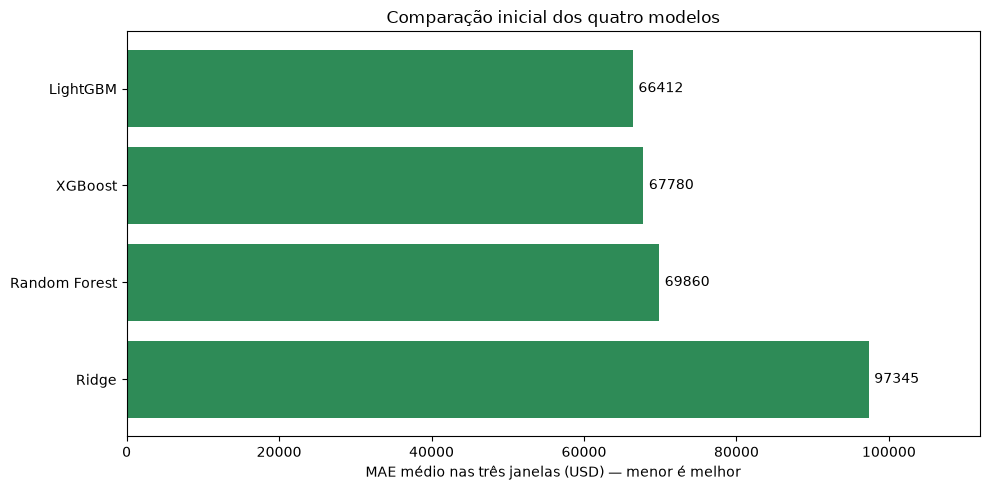

In [7]:
# Mostra o MAE inicial sem linhas de grade e com valores legíveis.
%matplotlib inline
figura, eixo = plt.subplots(figsize=(10, 5))
grafico_inicial = comparacao_inicial.sort_values("mae_medio", ascending=False)
barras = eixo.barh(grafico_inicial["modelo"], grafico_inicial["mae_medio"], color="#2E8B57")
eixo.bar_label(barras, fmt="%.0f", padding=4)
eixo.set(xlabel="MAE médio nas três janelas (USD) — menor é melhor", title="Comparação inicial dos quatro modelos")
eixo.set_xlim(0, grafico_inicial["mae_medio"].max() * 1.15)
eixo.grid(False)
figura.tight_layout()
figura.savefig(PASTA_GRAFICOS / "selecao_modelos_iniciais.png", dpi=150)
plt.show()

**O que o resultado mostra**

Cada barra representa o erro absoluto médio de um algoritmo, em USD. Não é percentual de erro nem erro máximo.

**Por que fizemos esta análise e o que decidimos**

O gráfico resume a comparação, enquanto a tabela anterior preserva variação, RMSE e custo. Uma barra menor identifica melhor resultado de validação nesta configuração, não desempenho garantido em outras épocas.

**Como ler:** a barra menor indica menor erro absoluto médio. LightGBM liderou a comparação inicial. A classificação vale para estas configurações e janelas; não significa que um algoritmo sempre será melhor em qualquer problema ou conjunto de parâmetros.

## 4. Investigando as features por grupos

Nos dois melhores candidatos, com parâmetros fixos, compararemos: 18 físicas; 25 físicas com derivadas; 50 com demografia sem `hous_val_amt`; e todas as 51 candidatas.

A comparação 18→25 investiga o grupo das derivadas. A comparação 25→50 investiga os demais indicadores demográficos. A comparação 50→51 isola a adição de `hous_val_amt`, mantendo as demais entradas. É uma investigação offline, sujeita à disponibilidade temporal dos indicadores. Um ganho estatístico não resolve essa dúvida de origem.

In [8]:
# Compara grupos nos dois melhores modelos e reaproveita a configuração inicial.
resultados_features = []
for nome_modelo in melhores_modelos:
    for grupo in grupos:
        resultados_features.append(avaliar_configuracao(nome_modelo, grupo, parametros_iniciais[nome_modelo]))
comparacao_features = resumir(resultados_features)
comparacao_features.to_csv(PASTA_RESULTADOS / "selecao_features.csv", index=False)
escolha_features = escolher_simples(resultados_features)
exibir(comparacao_features.sort_values(["modelo", "mae_medio"]).round(3))

LightGBM | fisicas_com_derivadas | log=False | MAE=66789.63
LightGBM | fisicas_demografia_sem_hous_val_amt | log=False | MAE=65372.33
LightGBM | todas_candidatas | log=False | MAE=65447.63
XGBoost | fisicas_com_derivadas | log=False | MAE=67830.56
XGBoost | fisicas_demografia_sem_hous_val_amt | log=False | MAE=65750.65
XGBoost | todas_candidatas | log=False | MAE=64932.86


,modelo,grupo,log_alvo,n_colunas,mae_medio,mae_desvio,rmse_medio,r2_medio,nao_positivas,segundos,origem
2,LightGBM,fisicas_demografia_sem_hous_val_amt,False,50,65372.327,2542.353,118439.672,0.886,0,1.177,execucao_atual
3,LightGBM,todas_candidatas,False,51,65447.627,3047.634,119320.147,0.884,0,1.168,execucao_atual
0,LightGBM,fisicas_originais,False,18,66411.626,3360.128,117255.357,0.888,0,0.747,execucao_atual
1,LightGBM,fisicas_com_derivadas,False,25,66789.635,3226.432,120140.458,0.882,0,0.842,execucao_atual
7,XGBoost,todas_candidatas,False,51,64932.858,2207.599,113051.861,0.897,0,1.777,execucao_atual
6,XGBoost,fisicas_demografia_sem_hous_val_amt,False,50,65750.649,2544.486,114554.622,0.894,0,1.722,execucao_atual
4,XGBoost,fisicas_originais,False,18,67780.265,2244.521,116100.569,0.891,0,1.365,execucao_atual
5,XGBoost,fisicas_com_derivadas,False,25,67830.559,2146.912,116722.016,0.890,0,1.352,execucao_atual


**O que o resultado mostra**

As linhas com o mesmo algoritmo usam parâmetros idênticos, mudando apenas o grupo de colunas. As configurações com físicas originais foram reaproveitadas.

**Por que fizemos esta análise e o que decidimos**

Preferimos menos colunas quando o erro está até 1% acima do menor MAE. A seleção é de um conjunto candidato, não um ranking individual das sete derivadas. Não testamos todas as combinações possíveis nem declaramos causalidade.

**Hipótese**

Se as derivadas ou a demografia reduzirem o erro de forma consistente nas janelas, há evidência favorável ao grupo naquele modelo. Se o ganho for pequeno ou instável, o conjunto simples pode ser suficiente.

**Resultado desta execução:** as sete derivadas aumentaram ligeiramente o MAE: de 66.412 para 66.790 no LightGBM e de 67.780 para 67.831 no XGBoost. Portanto, criar novas entradas não garantiu melhora.

Adicionar a demografia sem `hous_val_amt` ao conjunto com derivadas reduziu o MAE para 65.372 no LightGBM e 65.751 no XGBoost. Essa adição melhorou as três janelas nos dois modelos. Com todas as 51 entradas, XGBoost alcançou o menor MAE desta fase, de 64.933.

**Por que seguimos com LightGBM e 50 entradas?** Seu MAE ficou apenas 0,68% acima do menor valor. Pela regra definida antes dos experimentos, diferenças até 1% permitem preferir menos colunas. Entre os candidatos com 50 colunas, LightGBM teve menor erro. Assim, a decisão considerou a dependência de uma coluna adicional, e não apenas o menor número da tabela. A margem não demonstra equivalência estatística.

Não avaliamos demografia sem as derivadas. Portanto, não podemos afirmar que as 50 colunas sejam todas necessárias. A exclusão de `hous_val_amt` nesta escolha também não comprova vazamento de informação.

## 5. Preço original versus logaritmo

Avaliamos a configuração escolhida com `log(1 + preço)` no treino e `exp(previsão) − 1` na saída. As métricas continuam na escala original. O logaritmo muda o que o treinamento enfatiza e pode reduzir a influência de vendas muito caras, mas não garante menor MAE ou RMSE. Não aplicamos corte automático de previsões.

In [9]:
# Avalia uma transformação do alvo na combinação selecionada, sem alterar as features.
resultado_log = avaliar_configuracao(
    escolha_features["modelo"], escolha_features["grupo"], escolha_features["parametros"], usar_log=True
)
candidatos_antes_optuna = resultados_features + [resultado_log]
escolha_antes_optuna = escolher_simples(candidatos_antes_optuna)
comparacao_alvo = resumir([escolha_features, resultado_log])
comparacao_alvo.to_csv(PASTA_RESULTADOS / "selecao_transformacao_alvo.csv", index=False)
exibir(comparacao_alvo.round(3))

LightGBM | fisicas_demografia_sem_hous_val_amt | log=True | MAE=63121.53


,modelo,grupo,log_alvo,n_colunas,mae_medio,mae_desvio,rmse_medio,r2_medio,nao_positivas,segundos,origem
0,LightGBM,fisicas_demografia_sem_hous_val_amt,False,50,65372.327,2542.353,118439.672,0.886,0,1.177,execucao_atual
1,LightGBM,fisicas_demografia_sem_hous_val_amt,True,50,63121.532,3077.236,113537.137,0.896,0,1.374,execucao_atual


**O que o resultado mostra**

As duas linhas comparam preço original e logaritmo no mesmo algoritmo e grupo de features. Qualquer diferença de erro é medida depois de retornar à unidade do preço.

**Por que fizemos esta análise e o que decidimos**

A transformação foi testada em uma combinação, para controlar custo. Sua utilidade para outros algoritmos continua não investigada. A escolha anterior à busca considera todos os candidatos de features já avaliados, evitando perder uma alternativa melhor.

**Hipótese**

O logaritmo pode melhorar erros típicos e previsões não positivas, mas também piorar erros de imóveis caros. A tabela compara MAE e RMSE para não tratar a transformação como benefício automático.

**Resultado desta execução:** no LightGBM com 50 entradas, transformar o preço em log e desfazer a transformação nas previsões reduziu o MAE de 65.372 para 63.122, aproximadamente 3,44%. O RMSE também caiu, de 118.440 para 113.537. Mantivemos a transformação pela melhora observada; as métricas continuam na escala original do preço (USD), e não em log.

## 6. Busca pelos melhores hiperparâmetros com Optuna 

Agora ajustamos apenas o algoritmo, o grupo e a transformação escolhidos. O Optuna propõe hiperparâmetros e cada tentativa completa usa as três janelas. Tentativas podem ser interrompidas entre janelas quando pouco promissoras.

Limites: oito tentativas, 90 segundos para a busca e execução sequencial. O `timeout` limita o início de novas tentativas; não interrompe necessariamente um ajuste em andamento. Referência: [Study.optimize](https://optuna.readthedocs.io/en/stable/reference/generated/optuna.study.Study.html).

Se a busca não melhorar o candidato anterior, ele será mantido. Não há obrigação de escolher uma configuração só porque veio do Optuna.

In [10]:
# Busca poucos hiperparâmetros, preservando o candidato anterior como referência.
nome_busca = escolha_antes_optuna["modelo"]
grupo_busca = escolha_antes_optuna["grupo"]
log_busca = escolha_antes_optuna["log_alvo"]

def objetivo(tentativa):
    parametros = dict(parametros_iniciais[nome_busca])
    if nome_busca == "Ridge":
        parametros["alpha"] = tentativa.suggest_float("alpha", 0.01, 100.0, log=True)
    elif nome_busca == "Random Forest":
        parametros.update({
            "n_estimators": tentativa.suggest_int("n_estimators", 60, 140, step=20),
            "max_depth": tentativa.suggest_int("max_depth", 8, 20, step=4),
            "min_samples_leaf": tentativa.suggest_int("min_samples_leaf", 1, 6),
            "max_features": tentativa.suggest_float("max_features", 0.6, 1.0),
        })
    elif nome_busca == "XGBoost":
        parametros.update({
            "n_estimators": tentativa.suggest_int("n_estimators", 100, 220, step=40),
            "max_depth": tentativa.suggest_int("max_depth", 3, 6),
            "learning_rate": tentativa.suggest_float("learning_rate", 0.03, 0.12, log=True),
            "min_child_weight": tentativa.suggest_int("min_child_weight", 1, 10),
            "colsample_bytree": tentativa.suggest_float("colsample_bytree", 0.7, 1.0),
            "reg_lambda": tentativa.suggest_float("reg_lambda", 0.1, 10.0, log=True),
        })
    else:
        if nome_busca != 'LightGBM':
            raise ValueError('A busca espera LightGBM.')
        parametros.update({
            "n_estimators": tentativa.suggest_int("n_estimators", 100, 220, step=40),
            "num_leaves": tentativa.suggest_categorical("num_leaves", [15, 31, 63]),
            "learning_rate": tentativa.suggest_float("learning_rate", 0.03, 0.12, log=True),
            "min_child_samples": tentativa.suggest_int("min_child_samples", 15, 45, step=10),
            "colsample_bytree": tentativa.suggest_float("colsample_bytree", 0.7, 1.0),
            "reg_lambda": tentativa.suggest_float("reg_lambda", 0.1, 10.0, log=True),
        })
    resultado = avaliar_configuracao(nome_busca, grupo_busca, parametros, usar_log=log_busca, tentativa=tentativa)
    tentativa.set_user_attr("chave_experimento", chave_experimento(nome_busca, grupo_busca, parametros, log_busca))
    return resultado["mae_medio"]

estudo = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=SEMENTE, n_startup_trials=4),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=3, n_warmup_steps=1),
)
tempo_restante = max(0.0, TEMPO_EXPERIMENTOS_SEGUNDOS - segundos_ajustes)
if tempo_restante > 0:
    estudo.optimize(objetivo, n_trials=MAX_TENTATIVAS, timeout=min(TEMPO_OPTUNA_SEGUNDOS, tempo_restante),
                    n_jobs=1, gc_after_trial=True, show_progress_bar=False)

tentativas = estudo.trials_dataframe()
tentativas.to_csv(PASTA_RESULTADOS / "selecao_optuna_trials.csv", index=False)
# Considera somente configurações avaliadas nas três janelas.
escolha_final = escolher_simples(list(experimentos.values()))
comparacao_final = resumir([escolha_antes_optuna, escolha_final])
comparacao_final.insert(0, "momento", ["Antes do Optuna", "Configuração final"])
exibir(comparacao_final.round(3))

LightGBM | fisicas_demografia_sem_hous_val_amt | log=True | MAE=69190.82
LightGBM | fisicas_demografia_sem_hous_val_amt | log=True | MAE=62249.43
LightGBM | fisicas_demografia_sem_hous_val_amt | log=True | MAE=65262.78
LightGBM | fisicas_demografia_sem_hous_val_amt | log=True | MAE=62857.29
LightGBM | fisicas_demografia_sem_hous_val_amt | log=True | MAE=63803.44
LightGBM | fisicas_demografia_sem_hous_val_amt | log=True | MAE=63381.69
LightGBM | fisicas_demografia_sem_hous_val_amt | log=True | MAE=62578.93


,momento,modelo,grupo,log_alvo,n_colunas,mae_medio,mae_desvio,rmse_medio,r2_medio,nao_positivas,segundos,origem
0,Antes do Optuna,LightGBM,fisicas_demografia_sem_hous_val_amt,True,50,63121.532,3077.236,113537.137,0.896,0,1.374,execucao_atual
1,Configuração final,LightGBM,fisicas_demografia_sem_hous_val_amt,True,50,62249.431,3465.597,111291.128,0.900,0,1.531,execucao_atual


**O que o resultado mostra**

A tabela compara a configuração anterior à busca com a escolha final entre todas as configurações completas. Tentativas interrompidas não entram na seleção, porque não têm as três janelas avaliadas.

**Por que fizemos esta análise e o que decidimos**

O orçamento curto torna a busca exploratória, não exaustiva. Como a mesma CV orientou seleção de features e hiperparâmetros, o ganho observado precisa ser confirmado no teste final. Não consultaremos o teste para aumentar tentativas ou mudar a decisão.

**Resultado desta execução:** oito tentativas foram iniciadas; sete completaram as três janelas e uma foi interrompida por desempenho intermediário. O MAE caiu de 63.122 antes da busca para 62.249 na configuração final, melhora de aproximadamente 1,38%. A tentativa interrompida tem uma métrica parcial no CSV e não deve ser comparada diretamente às médias das três janelas dos candidatos completos.

## 7. Registro de hipóteses: evidência, alcance e decisão

A tabela abaixo quantifica mudanças relativas entre conjuntos, sempre com o mesmo algoritmo e parâmetros. Valor positivo significa redução do MAE; negativo significa piora. O número de janelas melhoradas mostra consistência, mas três janelas não são um teste de significância.

In [11]:
# Registra resultados pareados das hipóteses de ganho preditivo.
registro_hipoteses = []
transicoes = [
    ("Derivadas acrescentam ganho", "fisicas_originais", "fisicas_com_derivadas"),
    ("Demografia sem valor habitacional acrescenta ganho", "fisicas_com_derivadas", "fisicas_demografia_sem_hous_val_amt"),
    ("hous_val_amt acrescenta ganho incremental", "fisicas_demografia_sem_hous_val_amt", "todas_candidatas"),
]
for nome_modelo in melhores_modelos:
    for hipotese, grupo_base, grupo_novo in transicoes:
        base = experimentos[chave_experimento(nome_modelo, grupo_base, parametros_iniciais[nome_modelo], False)]
        novo = experimentos[chave_experimento(nome_modelo, grupo_novo, parametros_iniciais[nome_modelo], False)]
        ganho = (1 - novo["mae_medio"] / base["mae_medio"]) * 100
        janelas_melhores = sum(novo_j["mae"] < base_j["mae"] for base_j, novo_j in zip(base["janelas"], novo["janelas"]))
        registro_hipoteses.append({
            "hipotese": hipotese, "modelo": nome_modelo,
            "reducao_mae_pct": ganho, "janelas_melhores": janelas_melhores,
            "leitura": "ganho consistente observado" if ganho > 0 and janelas_melhores == 3 else
                       ("ganho médio com variação entre janelas" if ganho > 0 else "ganho médio não observado"),
            "limite": "avaliação com dados históricos; fonte e período dos indicadores pendentes" if grupo_novo != "fisicas_com_derivadas" else
                      "efeito do grupo, não de cada feature individual",
        })
registro_hipoteses = pd.DataFrame(registro_hipoteses)
registro_hipoteses.to_csv(PASTA_RESULTADOS / "selecao_hipoteses.csv", index=False)
with pd.option_context("display.max_colwidth", None, "display.max_columns", None):
    exibir(registro_hipoteses.round(3))

,hipotese,modelo,reducao_mae_pct,janelas_melhores,leitura,limite
0,Derivadas acrescentam ganho,LightGBM,-0.569,0,ganho médio não observado,"efeito do grupo, não de cada feature individual"
1,Demografia sem valor habitacional acrescenta ganho,LightGBM,2.122,3,ganho consistente observado,avaliação com dados históricos; fonte e período dos indicadores pendentes
2,hous_val_amt acrescenta ganho incremental,LightGBM,-0.115,1,ganho médio não observado,avaliação com dados históricos; fonte e período dos indicadores pendentes
3,Derivadas acrescentam ganho,XGBoost,-0.074,2,ganho médio não observado,"efeito do grupo, não de cada feature individual"
4,Demografia sem valor habitacional acrescenta ganho,XGBoost,3.066,3,ganho consistente observado,avaliação com dados históricos; fonte e período dos indicadores pendentes
5,hous_val_amt acrescenta ganho incremental,XGBoost,1.244,3,ganho consistente observado,avaliação com dados históricos; fonte e período dos indicadores pendentes


**O que o resultado mostra**

O registro informa se o grupo reduziu o erro e em quantas janelas isso ocorreu, para cada candidato selecionado. Pode haver ganho num algoritmo e não no outro.

**Por que fizemos esta análise e o que decidimos**

Uma hipótese pode não receber suporte no experimento sem ser universalmente falsa. A interpretação de zero em ano de reforma, a validade do registro com 33 quartos e a disponibilidade histórica de indicadores continuam dependendo da fonte; não são resolvidas por MAE menor.

**Como interpretar:** `reducao_mae_pct` positivo indica queda do erro; negativo indica aumento. `janelas_melhores = 3` significa melhora nos três períodos observados, não uma garantia para qualquer venda futura.

As derivadas, isoladamente, não reduziram o MAE médio de nenhum dos dois candidatos. A demografia sem `hous_val_amt`, adicionada ao grupo com derivadas, reduziu o erro em 2,12% no LightGBM e 3,07% no XGBoost, com melhora nas três janelas. Acrescentar `hous_val_amt` piorou o LightGBM em 0,12%, mas melhorou o XGBoost em 1,24%. O efeito depende do algoritmo e das demais entradas.

A leitura “ganho consistente observado” descreve estas janelas; não confirma causalidade, significância estatística ou disponibilidade histórica das informações.

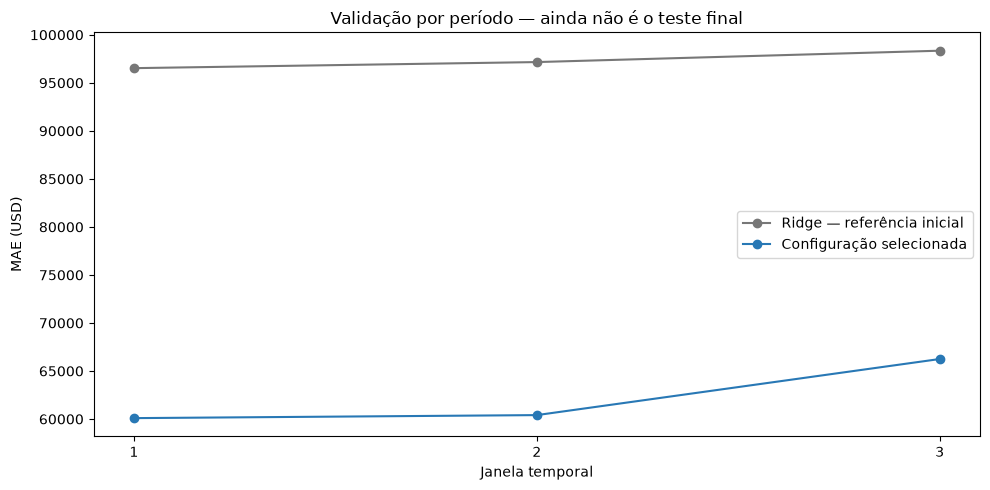

In [12]:
# Mostra a estabilidade da configuração final nas janelas originais.
%matplotlib inline
janelas_finais = pd.DataFrame(escolha_final["janelas"])
ridge_referencia = experimentos[chave_ridge]
figura, eixo = plt.subplots(figsize=(10, 5))
eixo.plot([1, 2, 3], [linha["mae"] for linha in ridge_referencia["janelas"]],
          marker="o", color="#777777", label="Ridge — referência inicial")
eixo.plot(janelas_finais["janela"], janelas_finais["mae"], marker="o",
          color="#2878B5", label="Configuração selecionada")
eixo.set_xticks([1, 2, 3])
eixo.set(xlabel="Janela temporal", ylabel="MAE (USD)",
         title="Validação por período — ainda não é o teste final")
eixo.ticklabel_format(axis="y", style="plain")
eixo.grid(False)
eixo.legend()
figura.tight_layout()
figura.savefig(PASTA_GRAFICOS / "selecao_mae_por_janela.png", dpi=150)
plt.show()

**O que o resultado mostra**

As linhas comparam a escolha final com Ridge nas mesmas vendas de validação. A configuração selecionada já foi escolhida usando essas janelas, portanto a curva não representa uma confirmação independente.

**Por que fizemos esta análise e o que decidimos**

O gráfico ajuda a examinar se o ganho médio se repete nos períodos. A etapa 06 terá a responsabilidade de avaliar o modelo congelado no teste, sem novos ajustes guiados por esse resultado.

**Resultado desta execução:** os MAEs do candidato final foram 60.094, 60.408 e 66.247 nas janelas 1, 2 e 3. Ele superou Ridge nos três períodos. A redução do MAE médio em relação ao baseline físico inicial foi de 36,05%.

**Hipótese:** o erro mais alto na terceira janela pode estar relacionado a mudanças no perfil dos imóveis vendidos ou nos preços. Este gráfico não identifica a causa. A análise de erros por segmento no notebook 06 ajudará a investigar esse comportamento.

## 8. Congelando a configuração para a avaliação final

Vamos salvar algoritmo, parâmetros, lista e ordem das features, transformação do alvo, regras de preparação e hashes das fontes. Não ajustaremos ainda um modelo em todo o conjunto de treino e validação e não produziremos métricas de teste nesta etapa.

O notebook 06 deverá reconstruir o pipeline congelado, treinar somente nas linhas `train_validation` e avaliar uma vez nas linhas `test`. A função de criação de features e o enriquecimento demográfico continuarão fazendo parte da preparação da futura inferência.

In [13]:
# Salva configuração, previsões de validação e trilha dos experimentos.
resumo_todos = resumir(list(experimentos.values())).sort_values("mae_medio")
resumo_todos.to_csv(PASTA_RESULTADOS / "selecao_experimentos.csv", index=False)
escolha_final["previsoes"].to_csv(PASTA_RESULTADOS / "selecao_previsoes_cv.csv", index=False)
janelas_finais.to_csv(PASTA_RESULTADOS / "selecao_janelas_final.csv", index=False)
configuracoes_serializadas = [{
    "chave": chave, **configuracao,
    "metricas_janelas": experimentos[chave]["janelas"]
} for chave, configuracao in configuracoes.items()]
(PASTA_RESULTADOS / "selecao_configuracoes.json").write_text(
    json.dumps(configuracoes_serializadas, indent=2, ensure_ascii=False), encoding="utf-8"
)

colunas_escolhidas = grupos[escolha_final["grupo"]]
usa_demografia = any(coluna not in grupos["fisicas_com_derivadas"] for coluna in colunas_escolhidas)
fontes_congeladas = {
    "data/processed/features_historico.csv": PASTA_DADOS / "features_historico.csv",
    "data/processed/identificacao_alvo_historico.csv": PASTA_DADOS / "identificacao_alvo_historico.csv",
    "data/processed/contrato_features.json": PASTA_DADOS / "contrato_features.json",
    "data/processed/split_manifest.csv": PASTA_DADOS / "split_manifest.csv",
    "data/processed/cv_manifest.csv": PASTA_DADOS / "cv_manifest.csv",
}
configuracao_final = {
    "versao": "selected_candidate_v2", "status": "configuracao_congelada_aguardando_teste_final",
    "modelo": escolha_final["modelo"], "grupo": escolha_final["grupo"],
    "colunas_ordenadas": colunas_escolhidas,
    "parametros": escolha_final["parametros"], "transformacao_alvo_log1p": escolha_final["log_alvo"],
    "random_state": SEMENTE, "threads": LIMITE_THREADS,
    "pipeline": {"numeric_imputer": "median", "keep_empty_features": True,
                 "numeric_scaler": "StandardScaler" if escolha_final["modelo"] == "Ridge" else None,
                 "categorical_columns": ["zipcode"], "categorical_imputer": "constant_UNKNOWN",
                 "onehot_drop": "first", "onehot_handle_unknown": "ignore",
                 "sparse": escolha_final["modelo"] == "Ridge",
                 "boosting_early_stopping": False,
                 "transform_output": "pandas" if escolha_final["modelo"] == "LightGBM" else "default"},
    "metricas_cv": {campo: escolha_final[campo] for campo in ["mae_medio", "mae_desvio", "rmse_medio", "r2_medio", "nao_positivas"]},
    "regra_selecao": {"metrica": "mean_fold_mae", "margem_simplicidade": MARGEM_SIMPLICIDADE,
                      "desempate": "menos_colunas_depois_menor_mae"},
    "test_evaluated": False,
    "usa_demografia": usa_demografia,
    "pendencias": ["fonte e significado das colunas originais a confirmar"] +
                  (["disponibilidade temporal dos indicadores usados precisa de confirmação antes do deploy"] if usa_demografia else []),
    "versoes": {"scikit_learn": sklearn.__version__, "optuna": optuna.__version__,
                "numpy": np.__version__, "pandas": pd.__version__,
                "xgboost": xgboost.__version__, "lightgbm": lightgbm.__version__},
    "source_sha256": {nome: hashlib.sha256(caminho.read_bytes()).hexdigest() for nome, caminho in fontes_congeladas.items()},
    "orcamento": {"fits_novos": contagem_ajustes, "fits_reaproveitados": 3,
                  "tentativas_optuna": len(estudo.trials), "max_tentativas_optuna": MAX_TENTATIVAS,
                  "tempo_experimentos_segundos": perf_counter() - inicio_experimentos,
                  "tempo_ajustes_segundos": segundos_ajustes,
                  "maior_rss_observado_mib": memoria_observada_mib,
                  "nota_memoria": "amostrada entre etapas, não pico exato"},
    "limitacoes": ["seleção e ajuste usam a mesma CV; avaliação final separada pendente",
                   "EDA anterior examinou todo o histórico", "busca pequena e sequencial, não exaustiva"],
}
(PASTA_ARTEFATOS / "configuracao_modelo_selecionado.json").write_text(
    json.dumps(configuracao_final, indent=2, ensure_ascii=False), encoding="utf-8"
)
exibir(pd.DataFrame({
    "item": ["Modelo", "Grupo", "Colunas", "Log do preço", "MAE de validação",
             "Ajustes novos", "Ajustes reaproveitados", "Tentativas Optuna", "Teste avaliado"],
    "valor": [escolha_final["modelo"], escolha_final["grupo"], len(colunas_escolhidas), escolha_final["log_alvo"],
              round(escolha_final["mae_medio"], 2), contagem_ajustes, 3, len(estudo.trials), False],
}))

,item,valor
0,Modelo,LightGBM
1,Grupo,fisicas_demografia_sem_hous_val_amt
2,Colunas,50
3,Log do preço,True
4,MAE de validação,62249.43
5,Ajustes novos,52
6,Ajustes reaproveitados,3
7,Tentativas Optuna,8
8,Teste avaliado,False


**O que o resultado mostra**

A saída identifica uma configuração congelada, não um modelo de produção já validado. Foram salvos os parâmetros e as previsões de validação para rastrear a decisão.

**Por que fizemos esta análise e o que decidimos**

A escolha pode ser mantida mesmo que Optuna não melhore o resultado anterior. Se utilizar demografia, sua disponibilidade temporal continua sendo uma pendência material antes da implantação. O teste não foi usado para escolher modelos ou aumentar a busca.

**Resultado desta execução:** selecionamos LightGBM com 50 entradas e log do preço. MAE médio de validação: 62.249; RMSE médio: 111.291; R² médio: 0,900. R² não significa “90% de acerto”. Nenhuma previsão de validação foi não positiva.

Foram 52 ajustes novos e três reaproveitados do notebook 04, em aproximadamente 30,53 segundos no registro salvo. A maior memória do processo observada entre etapas foi de cerca de 239,21 MiB; não é o pico exato nem o consumo total da máquina.

A configuração salva inclui parâmetros, versões de XGBoost e LightGBM, regras de preparação e ordem das colunas. Como utiliza demografia, sua disponibilidade na época das vendas permanece uma pendência antes da implantação.

## Complemento: MAPE na validação

Objetivo: expressar o erro em percentual sem alterar o critério de escolha.

In [14]:
# Mede erro relativo nas previsões já salvas, sem ajustar modelos.
previsoes_mape = pd.read_csv(PASTA_RESULTADOS / "selecao_previsoes_cv.csv")
if "modelo" not in previsoes_mape:
    previsoes_mape["modelo"] = json.loads(
        (PASTA_RESULTADOS.parent.parent / "artifacts/configuracao_modelo_selecionado.json").read_text(encoding="utf-8")
    )["modelo"]
if (not np.isfinite(previsoes_mape[["preco_real", "preco_previsto"]]).all().all()
        or not previsoes_mape["preco_real"].gt(0).all()):
    raise ValueError("MAPE exige preços reais positivos e previsões finitas.")
previsoes_mape["erro_percentual"] = (
    100 * (previsoes_mape["preco_previsto"] - previsoes_mape["preco_real"]).abs()
    / previsoes_mape["preco_real"]
)
mape_janelas = previsoes_mape.groupby(["modelo", "janela"], as_index=False).agg(
    MAPE_pct=("erro_percentual", "mean"), vendas=("source_row", "size")
)
# Distingue peso igual por janela de peso igual por venda.
mape_resumo = mape_janelas.groupby("modelo", as_index=False).agg(
    MAPE_medio_janelas_pct=("MAPE_pct", "mean")
).merge(previsoes_mape.groupby("modelo", as_index=False).agg(
    MAPE_todas_vendas_pct=("erro_percentual", "mean")
), on="modelo", validate="one_to_one")
mape_janelas.to_csv(PASTA_RESULTADOS / "selecao_mape_janelas.csv", index=False)
mape_resumo.to_csv(PASTA_RESULTADOS / "selecao_mape_resumo.csv", index=False)
exibir(mape_janelas.round(2))
exibir(mape_resumo.round(2))


,modelo,janela,MAPE_pct,vendas
0,LightGBM,1,11.18,2392
1,LightGBM,2,11.83,1626
2,LightGBM,3,12.90,1917


,modelo,MAPE_medio_janelas_pct,MAPE_todas_vendas_pct
0,LightGBM,11.97,11.92


**O que o resultado mostra:** MAPE médio das janelas — LightGBM: 11,97%.

**Por que medir:** calculamos o erro absoluto dividido pelo preço real de cada venda, multiplicamos por 100 e tiramos a média. Assim, o erro pode ser comunicado em percentual, complementando o MAE em USD.

A primeira tabela detalha cada janela. A segunda distingue média com peso igual por janela de média com peso igual por venda; os resultados podem diferir porque as janelas têm quantidades diferentes de vendas. MAPE não é o erro percentual mediano nem MAE dividido pelo preço médio.

**Decisão:** manter MAE como critério de seleção e usar MAPE para interpretação. Para o mesmo erro em dólares, imóveis mais baratos recebem maior peso relativo. Preços próximos de zero podem distorcer a métrica; os casos não são removidos silenciosamente. Esta inclusão não representa nova seleção ou nova avaliação independente.

No 05, o complemento usa as previsões salvas do candidato final. Não inventamos MAPE dos demais experimentos, cujas previsões individuais não foram exportadas.

## Conclusão para stakeholders

Comparamos **Ridge, Random Forest, XGBoost e LightGBM** nas mesmas três janelas temporais. A configuração selecionada é **LightGBM com 50 entradas e transformação logarítmica do preço**. O MAE médio de validação caiu de 97.345 no Ridge inicial para 62.249: redução de aproximadamente 36,05%. Essa comparação combina o efeito do algoritmo, do conjunto de entradas e dos parâmetros.

As hipóteses foram investigadas por mudanças de grupos nas mesmas vendas. As derivadas sozinhas não reduziram o erro médio; a adição de demografia trouxe melhora nos dois candidatos. Não foi demonstrado que todas as 50 colunas sejam necessárias. A disponibilidade histórica dos indicadores continua dependendo de confirmação da fonte.

A execução levou cerca de 30,53 segundos no registro salvo, com até duas threads. O teste final não participou da seleção. O próximo passo é reconstruir e treinar a configuração congelada no conjunto de treino e validação, depois avaliá-la no teste reservado no notebook 06.